# CBB Strength/Ranking Credibility Project

In [3]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


## Importing necessary data from March Madness Mania Dataset

In [5]:
cbb_matchups = pd.read_csv("MRegularSeasonCompactResults.csv")
cbb_matchups2025 = cbb_matchups[cbb_matchups['Season'] == 2025]

cbb_teams = pd.read_csv("MTeams.csv")

cbb_winners = pd.merge(cbb_teams, cbb_matchups2025, left_on=["TeamID"] , right_on=["WTeamID"])
cbb_winners.rename(columns = {"TeamName": "WTeamName"}, inplace = True)

cbb_w_and_l = pd.merge(cbb_winners, cbb_teams, left_on=["LTeamID"], right_on=["TeamID"])
cbb_w_and_l.rename(columns = {"TeamName": "LTeamName"}, inplace = True)
cbb_w_and_l.columns
cbb_w_and_l_teams = cbb_w_and_l[["WTeamName", "LTeamName"]]
cbb_w_and_l_teams

,WTeamName,LTeamName
0,Abilene Chr,Texas St
1,Abilene Chr,Southern Miss
2,Abilene Chr,NE Omaha
3,Abilene Chr,New Mexico St
4,Abilene Chr,TX Southern
...,...,...
5636,West Georgia,Tennessee Tech
5637,West Georgia,Austin Peay
5638,West Georgia,North Florida
5639,West Georgia,Bellarmine


## Creating Graphs from Data

### Directed Graph (Results)

In [8]:
cbb_graph = nx.DiGraph()
for i in range(0, len(cbb_teams)):
    cbb_graph.add_node(cbb_teams.loc[i]["TeamName"])

print(cbb_graph)

DiGraph with 381 nodes and 0 edges


<function matplotlib.pyplot.show(close=None, block=None)>

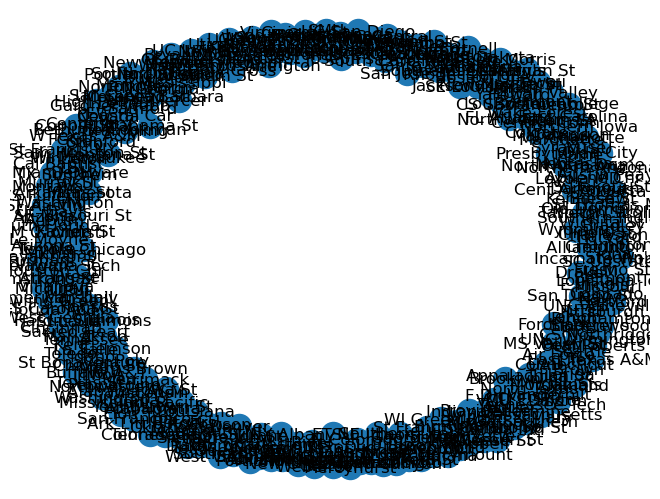

In [9]:
nx.draw(cbb_graph, with_labels = True)
plt.show

In [10]:
cbb_graph.edges

OutEdgeView([])

In [11]:
for k in range(0, len(cbb_w_and_l_teams)):
    if cbb_graph.has_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"]):
        cbb_graph[cbb_w_and_l_teams.loc[k]["LTeamName"]][cbb_w_and_l_teams.loc[k]["WTeamName"]]['weight'] += 1
    else:
        cbb_graph.add_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"], weight = 1)

print(cbb_graph)

DiGraph with 381 nodes and 4624 edges


<function matplotlib.pyplot.show(close=None, block=None)>

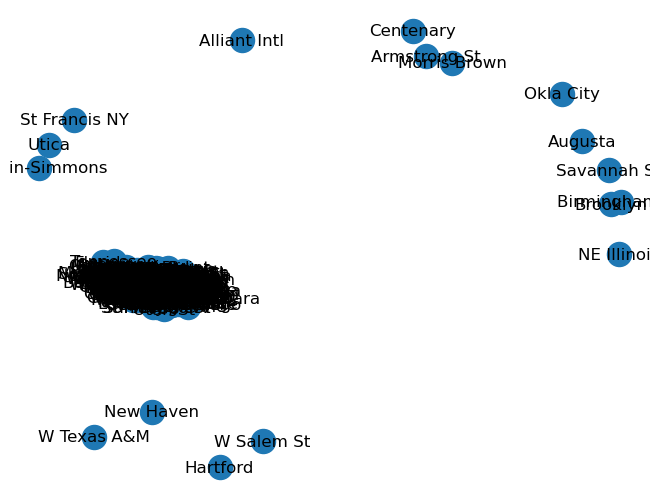

In [12]:
nx.draw(cbb_graph, with_labels = True)
plt.show

### Undirected Graph (Schedule)

In [14]:
cbb_graph_undirected = cbb_graph.to_undirected()
print(cbb_graph_undirected)

Graph with 381 nodes and 4043 edges


<function matplotlib.pyplot.show(close=None, block=None)>

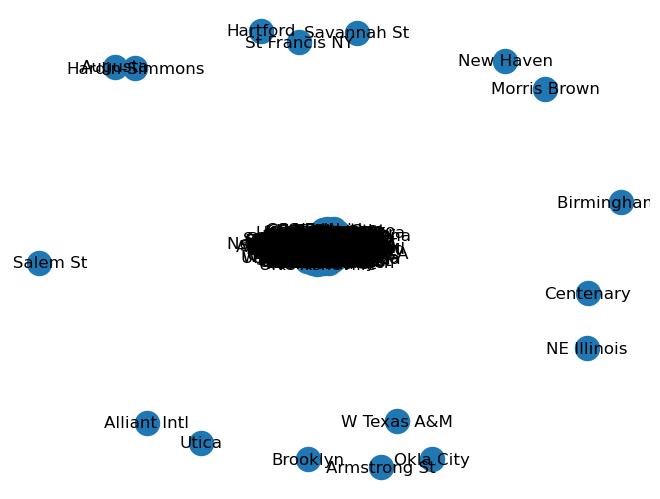

In [15]:
nx.draw(cbb_graph_undirected, with_labels = True)
plt.show

## Measures of Centrality

### In and Out Degree Centrality

In [18]:
cbb_graph.in_degree(weight="weight")
cbb_graph.out_degree(weight="weight")

in_degree_cent = nx.in_degree_centrality(cbb_graph)
print(max(in_degree_cent, key=in_degree_cent.get))
out_degree_cent = nx.out_degree_centrality(cbb_graph)
print(max(out_degree_cent, key=out_degree_cent.get))

Florida
Chicago St


### Eigenvector Centrality

In [20]:
eig_cent = nx.eigenvector_centrality(cbb_graph, weight="weight")
print(max(eig_cent, key=eig_cent.get))
eig_cent_sort_ascend = dict(sorted(eig_cent.items(), key=lambda item: item[1]))
print(eig_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest eigenvector centrality of any school that played in 2025 D1 season

Auburn
4.282469825957783e-05


### Katz Centrality

In [22]:
katz_cent = nx.katz_centrality_numpy(cbb_graph, weight="weight")
print(max(katz_cent, key=katz_cent.get))
print(min(katz_cent, key=katz_cent.get))

Houston
Robert Morris


### Closeness Centrality

In [24]:
close_cent = nx.closeness_centrality(cbb_graph)
print(max(close_cent, key=close_cent.get))
close_cent_sort_ascend = dict(sorted(close_cent.items(), key=lambda item: item[1]))
print(close_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest closeness centrality of any school that played in 2025 D1 season

Auburn
0.16989736713169498


### Betweenness Centrality

In [26]:
between_cent = nx.betweenness_centrality(cbb_graph, weight="weight")
print(max(between_cent, key=between_cent.get))
between_cent_sort_ascend = dict(sorted(between_cent.items(), key=lambda item: item[1]))
print(between_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest closeness centrality of any school that played in 2025 D1 season

Wichita St
6.226868536531537e-05


## Creating Laplacian for Credibility Approximation

### Handmade Laplacian

In [29]:
schedule_adj = nx.to_pandas_adjacency(cbb_graph_undirected)
schedule_degree_mat = np.zeros(schedule_adj.shape)
for i in range(0, len(schedule_adj)):
    schedule_degree_mat[i, i] = sum(schedule_adj.iloc[i])

laplacian_hand = schedule_degree_mat - schedule_adj
laplacian_hand

,Abilene Chr,Air Force,Akron,Alabama,Alabama A&M,Alabama St,SUNY Albany,Alcorn St,Alliant Intl,American Univ,...,St Thomas MN,Lindenwood,Queens NC,Southern Indiana,Stonehill,East Texas A&M,Le Moyne,Mercyhurst,West Georgia,New Haven
Abilene Chr,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
Air Force,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
Akron,0.0,0.0,31.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alabama,0.0,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alabama A&M,0.0,0.0,0.0,0.0,28.0,-2.0,0.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
East Texas A&M,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,28.0,0.0,0.0,0.0,0.0
Le Moyne,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,0.0,26.0,-1.0,0.0,0.0
Mercyhurst,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,0.0,-1.0,23.0,0.0,0.0
West Georgia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0


### NetworkX Laplacian (and is it equivalent to the handmade version)

In [31]:
schedule_lap = nx.laplacian_matrix(cbb_graph_undirected)
schedule_lap_dense = schedule_lap.todense()
is_same_test = np.array(laplacian_hand) == schedule_lap_dense
is_same_test.all()
# laplacian calculation by hand matches networkx calculation.

True

## Calculating Pseudoinverse of Laplacian

In [33]:
schedule_inv_lap = np.linalg.pinv(schedule_lap_dense)

## Calculating Credibility Approximation (Graph-Based)
$C_i^{\mathrm{graph}} = - \log((L^+)_{ii} + \epsilon)$

In [35]:
cred_approx = np.zeros(len(schedule_inv_lap))
epsilon = 1e-10
for i in range(0, len(schedule_inv_lap)):
    cred_approx[i] = -np.log(schedule_inv_lap[i, i] + epsilon)

cred_index1 = np.where(cred_approx >= 3.34)
cred_index2 = np.where(cred_approx <= 5)
cred_index = np.intersect1d(cred_index1, cred_index2)
cbb_teams.iloc[cred_index]["TeamName"] #most "credible" teams
cred_values = pd.Series(cred_approx, index = cbb_teams["TeamName"])

## Latent Strength (Bradley-Terry)
Suppose each teams has some unknown strength parameter $\theta_i \in \mathbb{R}$.

For teams $i$ and $j$, the Bradley-Terry model assumes the probability that $i$ defeats $j$ is as follows:
$$\mathbb{P}(i \text{ beats } j) = \sigma(\theta_i - \theta_j)$$
Where $\sigma(x) = \frac{1}{1 + e^{-x}}$ is the logistic function.

In [37]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

G = len(cbb_w_and_l)
n = len(cbb_teams)

latent_strength_framework = np.zeros((G, n))
latent_strength_matrix = pd.DataFrame(latent_strength_framework, columns = cbb_teams["TeamName"])

For creation of design matrix, team $i$ will be the team higher in the alphabet than team $j$ (arbitrary assignment for sake of consistency, as long as winning and losing teams are tracked properly, will not have an impact)
$$y_g = 
\begin{cases}
1, \text{ if team } i_g \text{ wins} \\
0, \text{ if team } j_g \text{ wins} 
\end{cases}$$

Our design matrix will be as follows:
$$X \in \mathbb{R}^{G \times n}$$
Where rows $\rightarrow$ games and columns $\rightarrow$ teams.
For game $g$ between teams $i_g$ and $j_g$, the design matrix row vector $X_g$ is defined as follows 
$$X_g = 
\begin{cases}
1, \text{ if } k = \text{ team } i_g \\
-1, \text{ if } k = \text{ team } j_g \\
0, \text{ otherwise} 
\end{cases}$$

In [39]:
y = np.zeros(G)
for k in range(0, G):
    if (cbb_w_and_l.loc[k]["WTeamName"] < cbb_w_and_l.loc[k]["LTeamName"]):
        y[k] = 1
        latent_strength_matrix.loc[k, cbb_w_and_l.loc[k]["WTeamName"]] = 1
        latent_strength_matrix.loc[k, cbb_w_and_l.loc[k]["LTeamName"]] = -1
    else:
        latent_strength_matrix.loc[k, cbb_w_and_l.loc[k]["WTeamName"]] = -1
        latent_strength_matrix.loc[k, cbb_w_and_l.loc[k]["LTeamName"]] = 1


We then find our latent strength values $\theta_i$ from the following equation:
$$X_g\boldsymbol{\theta} = \theta_{i_g} - \theta_{j_g}$$
Where $\boldsymbol{\theta} = (\theta_0, \theta_1, ..., \theta_{n-1})^{\top}$ (note that our design matrix is zero indexed for games)

Our model predicting the probability of team $i$ winning then becomes as follows:
$$\mathbb{P}(y_g = 1) = \sigma(X_g\boldsymbol{\theta})$$

We find our latent strength estimates by maximizing the log-likelihood of our vector $\boldsymbol{\theta}$
$$\mathscr{l}(\boldsymbol{\theta}) = \sum_{g=0}^G \Big[y_g \log\big(\sigma(X_g\boldsymbol{\theta})\big) + (1 - y_g) \log\big(1 - \sigma(X_g\boldsymbol{\theta})\big)\Big]$$
Since we have no closed form solution for $\boldsymbol{\theta}$, we will use the quasi-Newton optimization function L-BFGS to find our estimate $\hat{\boldsymbol{\theta}}$. 

To do this, we need the gradient of the log-likelihood as well
$$\nabla_{\theta}\mathscr{l}(\boldsymbol{\theta}) = \sum_{g=1}^G X_g\Big(y_g - \sigma(X_g\boldsymbol{\theta})\Big)$$

In [42]:
def neg_log_likelihood(theta, X, y):
    p = sigmoid(X @ theta)
    epsilon = 1e-10
    p = np.clip(p, epsilon, 1-epsilon)
    return -np.sum(y*np.log(p) + (1-y)*np.log(1-p))

def neg_log_likelihood_grad(theta, X, y):
    p = sigmoid(X @ theta)
    return X.T @ (p-y)

Optimization Trial Run

In [44]:
from scipy.optimize import minimize
np.random.seed(352)
theta0 = np.random.rand(n)

results = minimize(
    neg_log_likelihood,
    theta0,
    args=(latent_strength_matrix, y,),
    method="L-BFGS-B",
    jac=neg_log_likelihood_grad,
)


In [45]:
results

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 2700.132349402231
        x: [-2.840e-01 -1.681e+00 ... -2.373e+00  9.658e-01]
      nit: 20
      jac: [-4.177e-05  2.757e-04 ...  2.425e-05  0.000e+00]
     nfev: 22
     njev: 22
 hess_inv: <381x381 LbfgsInvHessProduct with dtype=float64>

In [46]:
strength_values = results.x - (1/len(results.x))*sum(results.x) #theta adjustment s.t. sum of all theta = 0
team_strength = pd.Series(strength_values, index = cbb_teams["TeamName"])
latent_strength_byteam = team_strength.sort_values(ascending = False)
print(latent_strength_byteam.head(10))
print(latent_strength_byteam.tail(10))

TeamName
Florida        5.763947
Auburn         5.688456
Tennessee      5.177185
Duke           5.035595
Alabama        5.017129
Houston        4.878692
Kentucky       4.336717
Michigan St    4.277220
Mississippi    4.215026
Texas A&M      4.181787
dtype: float64
TeamName
Coppin St        -3.301216
Canisius         -3.320172
Chicago St       -3.343750
Bellarmine       -3.603144
Alabama A&M      -3.845897
MD E Shore       -4.222826
Citadel          -4.667714
Prairie View     -4.924423
Ark Pine Bluff   -5.014702
MS Valley St     -6.511853
dtype: float64


## Tournament Predictions

### Baseline Model
$$\mathbb{P}(i > j) = \sigma\Big(\beta_0 + \beta_1(\theta_i - \theta_j)\Big)$$
For our default model, we will set parameters $\beta_0 = 0$ and $\beta_1 = 1$

In [49]:
cbb_tourney = pd.read_csv("MNCAATourneyCompactResults.csv")
cbb_tourney2025 = cbb_tourney[cbb_tourney["Season"] == 2025]

tourney_winners = pd.merge(cbb_teams, cbb_tourney2025, left_on=["TeamID"] , right_on=["WTeamID"])
tourney_winners.rename(columns = {"TeamName": "WTeamName"}, inplace = True)

tourney_w_and_l = pd.merge(tourney_winners, cbb_teams, left_on=["LTeamID"], right_on=["TeamID"])
tourney_w_and_l.rename(columns = {"TeamName": "LTeamName"}, inplace = True)
tourney_w_and_l_teams = tourney_w_and_l[["WTeamName", "LTeamName"]]
tourney_w_and_l_teams

,WTeamName,LTeamName
0,Alabama,Robert Morris
1,Alabama,St Mary's CA
2,Alabama,BYU
3,Alabama St,St Francis PA
4,Arizona,Akron
...,...,...
62,Texas Tech,Drake
63,Texas Tech,Arkansas
64,UCLA,Utah St
65,Wisconsin,Montana


In [50]:
def predict_model(theta, index, n, b0 = 0, b1 = 1):
    win_probs = np.zeros(n)
    for l in range(0, n):
        win_probs[l] = sigmoid(b0 + b1*(theta[index.loc[l]["WTeamName"]] - theta[index.loc[l]["LTeamName"]]))
        
    return win_probs

In [51]:
win_probs = predict_model(team_strength, tourney_w_and_l_teams, len(tourney_w_and_l_teams))
base = tourney_w_and_l_teams[win_probs < 0.5] # upsets based on solely latent strength

### Extended Model
$$\mathbb{P}(i > j) = \sigma\Big(\beta_0 + \beta_1(\theta_i - \theta_j) + \beta_2(C_i - C_j)\Big)$$
For our more involved model, we include our credibility approximation and default parameters will be set as $\beta_0 = 0, \beta_1 = 1, \beta_2 = 1$

In [53]:
def predict_model_extended(theta, C, index, n, b0 = 0, b1 = 1, b2 = 1):
    win_probs_extended = np.zeros(n)
    for l in range(0, n):
        win_probs_extended[l] = sigmoid(b0 + b1*(theta[index.loc[l]["WTeamName"]] - theta[index.loc[l]["LTeamName"]] + b2*(C[index.loc[l]["WTeamName"]] - C[index.loc[l]["LTeamName"]])))
        
    return win_probs_extended

In [54]:
extended_win_probs = predict_model_extended(team_strength, cred_values, tourney_w_and_l_teams, len(tourney_w_and_l_teams))
extend = tourney_w_and_l_teams[extended_win_probs < 0.5] #upsets based on both latent strength and our credibility index

In [90]:
(base.all() == extend.all())

WTeamName    True
LTeamName    True
dtype: bool

Models under default $\beta$ parameters show no difference from one another, going to test for series of other parameters

In [57]:
b_1 = np.linspace(0.1, 1, 10)
b_2 = np.linspace(1, 5, 10)

for b1 in b_1:
    basic_model = predict_model(team_strength, tourney_w_and_l_teams, len(tourney_w_and_l_teams), 0, b1)
    base_test = tourney_w_and_l_teams[basic_model < 0.5]
    for b2 in b_2:
        extension_model = predict_model_extended(team_strength, cred_values, tourney_w_and_l_teams, len(tourney_w_and_l_teams), 0, b1, b2)
        extend_test = tourney_w_and_l_teams[extension_model < 0.5]
        if (base_test.all() != extend_test.all()).iloc[0] | (base_test.all() != extend_test.all()).iloc[1]:
            print(base_test)
            print(extend_test)

b_1 = np.linspace(1, 5, 10)
b_2 = np.linspace(0.1, 1, 10)

for b1 in b_1:
    basic_model = predict_model(team_strength, tourney_w_and_l_teams, len(tourney_w_and_l_teams), 0, b1)
    base_test = tourney_w_and_l_teams[basic_model < 0.5]
    for b2 in b_2:
        extension_model = predict_model_extended(team_strength, cred_values, tourney_w_and_l_teams, len(tourney_w_and_l_teams), 0, b1, b2)
        extend_test = tourney_w_and_l_teams[extension_model < 0.5]
        if (base_test.all() != extend_test.all()).iloc[0] | (base_test.all() != extend_test.all()).iloc[1]:
            print(base_test)
            print(extend_test)


Models continue to show no change even with variation in our $\beta$ parameters